In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("Sales Data.csv")

# Check first 5 rows
print(df.head())

# Check info
print(df.info())

   Unnamed: 0  Order ID               Product  Quantity Ordered  Price Each  \
0           0    295665    Macbook Pro Laptop                 1     1700.00   
1           1    295666    LG Washing Machine                 1      600.00   
2           2    295667  USB-C Charging Cable                 1       11.95   
3           3    295668      27in FHD Monitor                 1      149.99   
4           4    295669  USB-C Charging Cable                 1       11.95   

            Order Date                        Purchase Address  Month  \
0  2019-12-30 00:01:00  136 Church St, New York City, NY 10001     12   
1  2019-12-29 07:03:00     562 2nd St, New York City, NY 10001     12   
2  2019-12-12 18:21:00    277 Main St, New York City, NY 10001     12   
3  2019-12-22 15:13:00     410 6th St, San Francisco, CA 94016     12   
4  2019-12-18 12:38:00           43 Hill St, Atlanta, GA 30301     12   

     Sales            City  Hour  
0  1700.00   New York City     0  
1   600.00   New

In [15]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values
df['Quantity Ordered'] = df['Quantity Ordered'].fillna(0)
df['Price Each'] = df['Price Each'].fillna(0)

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.dropna(subset=['Order Date'])  # remove invalid dates

In [16]:
# Total Sale
df['Total_Sale'] = df['Quantity Ordered'] * df['Price Each']

# Extract Month and Hour if not present
df['Month'] = df['Order Date'].dt.month
df['Hour'] = df['Order Date'].dt.hour

In [17]:
total_revenue = df['Total_Sale'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 34492035.97


In [19]:
# Top five products
top_products = df.groupby('Product')['Total_Sale'].sum().sort_values(ascending=False).head(5)
top_products

Product
Macbook Pro Laptop        8037600.00
iPhone                    4794300.00
ThinkPad Laptop           4129958.70
Google Phone              3319200.00
27in 4K Gaming Monitor    2435097.56
Name: Total_Sale, dtype: float64

In [ ]:
# Monthly sale
monthly_sales = df.groupby('Month')['Total_Sale'].sum()
monthly_sales

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Total_Sale, dtype: float64

In [ ]:
# City-Wise sale
city_sales = df.groupby('City')['Total_Sale'].sum()
city_sales

City
Atlanta          2795498.58
Austin           1819581.75
Boston           3661642.01
Dallas           2767975.40
Los Angeles      5452570.80
New York City    4664317.43
Portland         2320490.61
San Francisco    8262203.91
Seattle          2747755.48
Name: Total_Sale, dtype: float64

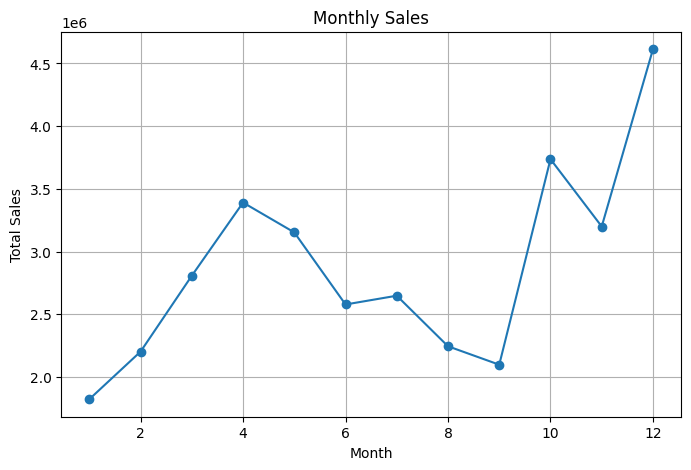

In [ ]:
# Visualization : Monthly sale
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o', title='Monthly Sales')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

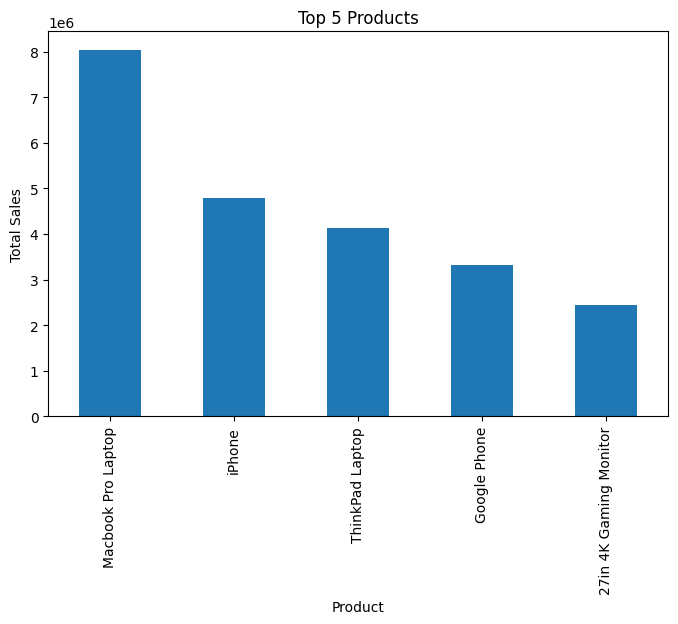

In [23]:
# Top 5 pproducts bar chart
plt.figure(figsize=(8,5))
top_products.plot(kind='bar', title='Top 5 Products')
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()

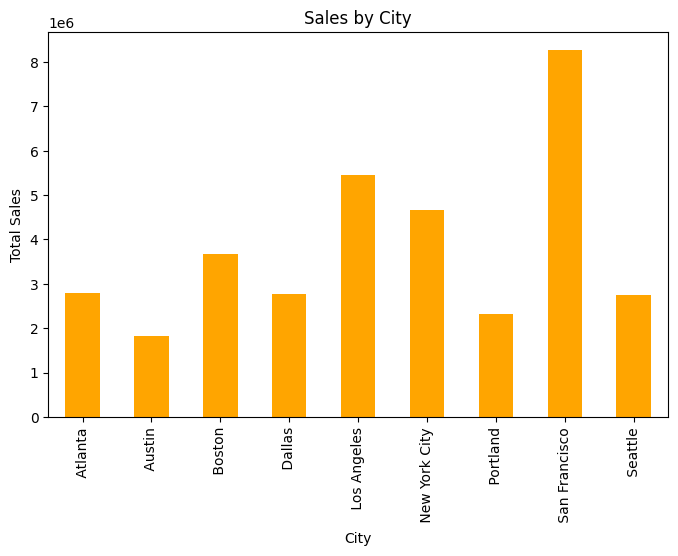

In [24]:
# City sales bar chart
plt.figure(figsize=(8,5))
city_sales.plot(kind='bar', color='orange', title='Sales by City')
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

In [25]:
# Export cleaned data set
df.to_csv("sales_cleaned.csv", index=False)
print("Cleaned dataset saved as sales_cleaned.csv")

Cleaned dataset saved as sales_cleaned.csv
